<a href="https://colab.research.google.com/github/nicole-whitlock/games/blob/main/Evaluation_and_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import tensorflow as tf
from transformers import TFDistilBertModel
import numpy as np
from tqdm import tqdm
from transformers import DistilBertTokenizer
import re

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import random

In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [5]:
dir = '/content/drive/MyDrive/ML_models'

In [ ]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

In [7]:
test_input_ids = np.load('/content/drive/MyDrive/ML_models/test_input_ids.npy')
test_attention_mask = np.load('/content/drive/MyDrive/ML_models/test_attention_mask.npy')
test_labels = np.load('/content/drive/MyDrive/ML_models/test_labels.npy')
test_scores = np.load('/content/drive/MyDrive/ML_models/test_original_scores.npy')

In [8]:
MAX_LEN = 128
NUM_CLASSES = 3
BATCH_SIZE = 16

In [9]:
test_dataset = tf.data.Dataset.from_tensor_slices((
    {
        'input_ids': test_input_ids,
        'attention_mask': test_attention_mask
    },
    test_labels
))
test_dataset = test_dataset.batch(BATCH_SIZE)

In [10]:
class DistilBertLayer(tf.keras.layers.Layer):
    def __init__(self, bert_model, **kwargs):
        super(DistilBertLayer, self).__init__(**kwargs)
        self.bert_model = bert_model

    def call(self, inputs):
        input_ids, attention_mask = inputs
        bert_output = self.bert_model(input_ids, attention_mask=attention_mask, return_dict=True)
        return bert_output["last_hidden_state"]

def create_model(bert_model, max_len=MAX_LEN, num_classes=NUM_CLASSES):
    # Define inputs
    input_ids = tf.keras.Input(shape=(max_len,), dtype='int32', name='input_ids')
    attention_masks = tf.keras.Input(shape=(max_len,), dtype='int32', name='attention_mask')

    # BERT layer
    bert_output = DistilBertLayer(bert_model)([input_ids, attention_masks])

    # Global average pooling
    pooled_output = tf.keras.layers.GlobalAveragePooling1D()(bert_output)

    # Dropout for regularization
    dropout = tf.keras.layers.Dropout(0.3)(pooled_output)

    # Output layer
    output = tf.keras.layers.Dense(num_classes, activation='softmax')(dropout)

    # Create model
    model = tf.keras.models.Model(inputs={'input_ids': input_ids, 'attention_mask': attention_masks}, outputs=output)

    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
base_model = TFDistilBertModel.from_pretrained('distilbert-base-uncased')
model = create_model(base_model)

In [12]:
sample_input_ids = tf.convert_to_tensor(test_input_ids[:1])
sample_attention_mask = tf.convert_to_tensor(test_attention_mask[:1])
_ = model({'input_ids': sample_input_ids, 'attention_mask': sample_attention_mask})

In [ ]:
weights_path = '/content/drive/MyDrive/ML_models/distilbert_layer_sentiment_weights.h5'
model.load_weights(weights_path)

print("Model weights loaded successfully!")


In [14]:
# predictions = model.predict(test_dataset)
# predicted_classes = np.argmax(predictions, axis=1)

In [15]:
# np.save(f'{dir}/predictions.npy', predictions)
# np.save(f'{dir}/predicted_classes.npy', predicted_classes)

In [16]:
predicted_classes = np.load(f'{dir}/predicted_classes.npy')
predictions = np.load(f'{dir}/predictions.npy')
test_labels = np.load('/content/drive/MyDrive/ML_models/test_labels.npy')

In [18]:
class_names = ['Negative', 'Neutral', 'Positive']

cm = confusion_matrix(test_labels, predicted_classes)
accuracy = accuracy_score(test_labels, predicted_classes)
precision_per_class = precision_score(test_labels, predicted_classes, average=None)
recall_per_class = recall_score(test_labels, predicted_classes, average=None)
f1_per_class = f1_score(test_labels, predicted_classes, average=None)
precision_macro = precision_score(test_labels, predicted_classes, average='macro')
recall_macro = recall_score(test_labels, predicted_classes, average='macro')
f1_macro = f1_score(test_labels, predicted_classes, average='macro')
precision_weighted = precision_score(test_labels, predicted_classes, average='weighted')
recall_weighted = recall_score(test_labels, predicted_classes, average='weighted')
f1_weighted = f1_score(test_labels, predicted_classes, average='weighted')

print(f"Overall Accuracy: {accuracy:.4f}")
print("\nPer-class Metrics:")
for i, class_name in enumerate(class_names):
    print(f"{class_name}:")
    print(f"  Precision: {precision_per_class[i]:.4f}")
    print(f"  Recall: {recall_per_class[i]:.4f}")
    print(f"  F1 Score: {f1_per_class[i]:.4f}")

print("\nAggregate Metrics:")
print(f"Macro Precision: {precision_macro:.4f}")
print(f"Macro Recall: {recall_macro:.4f}")
print(f"Macro F1 Score: {f1_macro:.4f}")
print(f"Weighted Precision: {precision_weighted:.4f}")
print(f"Weighted Recall: {recall_weighted:.4f}")
print(f"Weighted F1 Score: {f1_weighted:.4f}")

Overall Accuracy: 0.8649

Per-class Metrics:
Negative:
  Precision: 0.8425
  Recall: 0.8174
  F1 Score: 0.8298
Neutral:
  Precision: 0.5754
  Recall: 0.5357
  F1 Score: 0.5548
Positive:
  Precision: 0.9227
  Recall: 0.9430
  F1 Score: 0.9327

Aggregate Metrics:
Macro Precision: 0.7802
Macro Recall: 0.7654
Macro F1 Score: 0.7725
Weighted Precision: 0.8612
Weighted Recall: 0.8649
Weighted F1 Score: 0.8629


Text(50.722222222222214, 0.5, 'True Label')

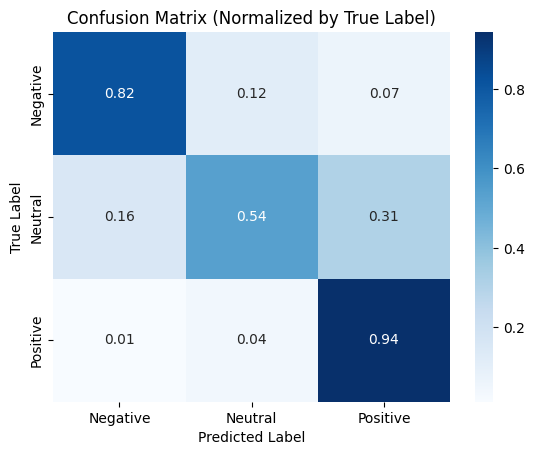

In [33]:
plt.subplot()
cm_normalized = confusion_matrix(test_labels, predicted_classes, normalize='true')
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Normalized by True Label)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

In [20]:
# Look at mislabeled neutral

In [21]:
mislabeled_indices = np.where(predicted_classes != test_labels)[0]
print(f"Total mislabeled examples: {len(mislabeled_indices)}")

Total mislabeled examples: 40001


In [22]:
def decode_text(input_ids):
    # Remove padding tokens
    input_ids = input_ids[input_ids != 0]
    # Convert back to text
    return tokenizer.decode(input_ids)

In [23]:
random.shuffle(mislabeled_indices)

num_examples_to_show = min(10, len(mislabeled_indices))


for i in range(num_examples_to_show):
    idx = mislabeled_indices[i]


    try:
        text = decode_text(test_input_ids[idx])
    except:
        text = f"Example #{idx}"

    true_label = class_names[test_labels[idx]]
    pred_label = class_names[predicted_classes[idx]]
    confidence = predictions[idx][predicted_classes[idx]] * 100
    original_score = test_scores[idx]

    print(f"Example {i+1}:")
    print(f"Text: {text}")
    print(f"True label: {true_label}")
    print(f"Predicted label: {pred_label} (confidence: {confidence:.2f}%)")
    print(f"Original Score: {original_score}")

Example 1:
Text: [CLS] if cheech and chong meet " el mariachi " sounds good to you, then pick up total overdose stat. if you can't stand the notion of a mexican shooting range scored on accuracy and presentation, then you may want to hold onto those pesos. [SEP]
True label: Positive
Predicted label: Neutral (confidence: 60.09%)
Original Score: 78.0
Example 2:
Text: [CLS] are you kidding me? did someone actually say, that developers of the witcher 2 are from nineteenth century? this game is supposed to resemble a medieval setting with monsters and such. try 7 centuries earlier. mysoginistic? how about realistic? if you think today's world is a man's world, how do you think it looked like in the 1200s? add monsters and magic into the mix, and basicly any women that have any say in what goes on in the world are witches, sorcereses, and noblewomen. and female monsters of any kind. : ) that's it [SEP]
True label: Positive
Predicted label: Negative (confidence: 69.79%)
Original Score: 90.0
E

In [25]:
def predict_sentiment(text, model, tokenizer, max_len=128):

    text = re.sub(r'\s+', ' ', text.strip())

    encoded = tokenizer.encode_plus(
      text,
      add_special_tokens=True,
      max_length=max_len,
      padding='max_length',
      truncation=True,
      return_attention_mask=True,
      return_tensors='tf'
    )

    input_ids = encoded['input_ids']
    attention_mask = encoded['attention_mask']


    prediction = model.predict({
        'input_ids': input_ids,
        'attention_mask': attention_mask
    })

    class_idx = np.argmax(prediction, axis=1)[0]
    confidence = float(prediction[0][class_idx])

    sentiment_labels = {0: 'negative', 1: 'neutral', 2: 'positive'}
    sentiment = sentiment_labels[class_idx]


    return {
        'class': int(class_idx),
        'sentiment': sentiment,
        'confidence': confidence,
        'scores': {label: float(score) for label, score in zip(sentiment_labels.values(), prediction[0])}
    }


In [27]:

sample_text = "I loved it, but it sucked"
result = predict_sentiment(sample_text, model, tokenizer)

print(f"Text: {sample_text}")
print(f"Predicted sentiment: {result['sentiment']}")
print(f"Confidence: {result['confidence']:.4f}")
print("Scores:")
for sentiment, score in result['scores'].items():
    print(f"  {sentiment}: {score:.4f}")

1/1 [==============================] - 0s 129ms/step
Text: I loved it, but it sucked
Predicted sentiment: positive
Confidence: 0.8291
Scores:
  negative: 0.0660
  neutral: 0.1049
  positive: 0.8291
